In [16]:
%matplotlib inline 
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes
import pandas as pd
import glob
import matplotlib.patches as mpatches
import os
import tables_io
from astropy.table import Table
from astropy.io import ascii
from astropy.coordinates import SkyCoord
import astropy.units as u
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['axes.linewidth'] = 2.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load in the Original Files

In [18]:
# This has coords, photometry, and number of filters the object is detected in (7=max)
main_obj_file = pd.read_csv('HLTDS_field/matched_photometry.csv')
obj_coords = SkyCoord(ra = np.array(main_obj_file['RA'])*u.deg, dec = np.array(main_obj_file['DEC'])*u.deg, frame='icrs')
objid = np.array(main_obj_file['objid'])
num_det = np.array(main_obj_file['N_FILTERS'])

# Truth catalog has OpenUniverse ID, coords and object type
truth = ascii.read("HLTDS_field/H158/master_truth_H158_field5356473.txt")
truth_coords = SkyCoord(ra = np.array(truth['ra'])*u.deg, dec = np.array(truth['dec'])*u.deg, frame='icrs')
truth_type = np.array(truth['obj_type'])

# Truth catalog has OpenUniverse ID, coords, and redshift
gal_truth = pd.read_parquet("HLTDS_field/galaxy_rtid5356473.parquet")
gal_coords = SkyCoord(ra = np.array(gal_truth['ra'])*u.deg, dec = np.array(gal_truth['dec'])*u.deg, frame='icrs')
gal_redshift = np.array(gal_truth['redshift'])

# Combine Truth Catalog with Galaxy Redshifts

In [44]:
# The truth catalog's object_id matches galaxy_id in the galaxy truth file,
# so we can merge on ID directly (every galaxy in the truth catalog has a match)
# Stars and transients get NaN for redshift
combined_truth = truth.to_pandas().merge(
    gal_truth[['galaxy_id', 'redshift', 'redshiftHubble']],
    left_on='object_id', right_on='galaxy_id', how='left'
).drop(columns='galaxy_id')

print(combined_truth['obj_type'].value_counts())
print('Galaxies missing a redshift:', 
      combined_truth.loc[combined_truth['obj_type'] == 'galaxy', 'redshift'].isna().sum())
combined_truth

obj_type
galaxy       47009
star           470
transient       15
Name: count, dtype: int64
Galaxies missing a redshift: 0


,object_id,ra,dec,flux,realized_flux,mag,obj_type,x,y,redshift,redshiftHubble
0,10431101688546,9.445577,-44.795196,105.627258,105.0,10.014725,galaxy,6999.317383,283.152527,1.816038,1.818262
1,10431200504280,9.445644,-44.787916,34.401257,35.0,11.232729,galaxy,6998.186035,521.417175,2.222025,2.220490
2,41024098445,9.445655,-44.768318,2593.583008,2583.0,6.539414,star,6999.116699,1162.788452,NaN,NaN
3,10431200693165,9.445683,-44.791632,51.813652,52.0,10.788054,galaxy,6997.057129,399.810516,2.264644,2.269079
4,10431200504279,9.445728,-44.787804,16.684641,19.0,12.018373,galaxy,6996.243164,525.099365,2.222681,2.220433
...,...,...,...,...,...,...,...,...,...,...,...
47489,10431101683007,9.746804,-44.758950,578.516357,584.5,8.168376,galaxy,1.320855,1469.411133,1.808611,1.804986
47490,10431000153464,9.746813,-44.741042,40.489849,50.0,11.055799,galaxy,0.044010,2055.461914,0.528104,0.523923
47491,10431202072856,9.746851,-44.799782,112.752983,117.0,9.943845,galaxy,2.720680,133.063339,2.967318,2.969419
47492,10431100781157,9.746873,-44.778998,19.269495,24.5,11.861989,galaxy,0.937394,813.264526,1.409954,1.408626


# Load the PZFlow and LePhare Output Files

In [21]:
pzflow_res = np.load('pzflow_hltds.npz')
lephare_res = np.load('lephare_hltds_results.npz')

# Match Detected Objects to the Truth Catalog

In [50]:
# pzflow_res['objid'] is identical to main_obj_file['objid'], so the PZFlow results
# are already row-aligned with main_obj_file -- we only need to match on coordinates
# to the truth catalog. combined_truth has the same row order as truth, so
# truth_coords lines up with it directly.
match_idx, match_sep, _ = obj_coords.match_to_catalog_sky(truth_coords)

max_sep = 0.2 * u.arcsec
has_match = match_sep < max_sep

obj_type = np.where(has_match, np.array(combined_truth['obj_type'])[match_idx], 'unmatched')
true_z = np.where(has_match, np.array(combined_truth['redshift'])[match_idx], np.nan)

print(pd.Series(obj_type).value_counts())

galaxy       14276
unmatched     8842
star           462
transient       11
Name: count, dtype: int64


# PZFlow

galaxy: 14276 objects, 0 with z_median == NaN
star: 462 objects, 0 with z_median == NaN
transient: 11 objects, 0 with z_median == NaN


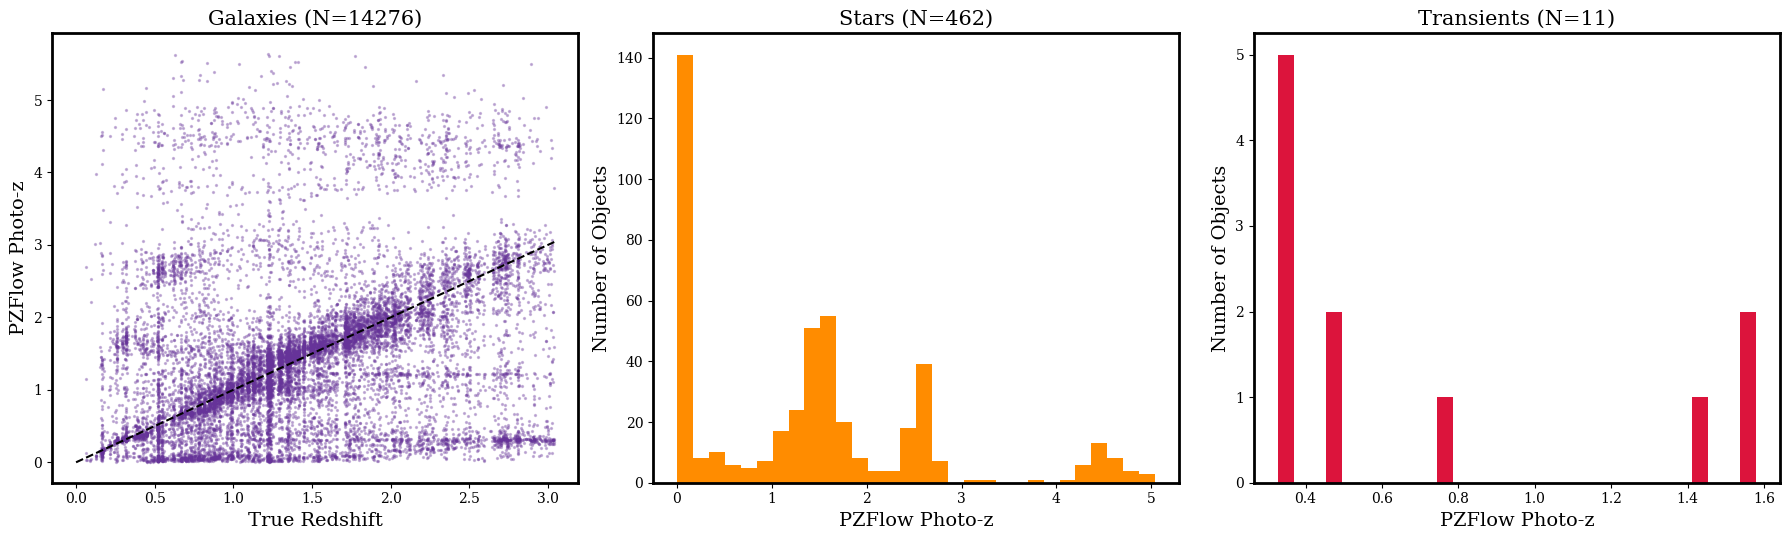

In [52]:
z_median = pzflow_res['z_median']

for cat in ['galaxy', 'star', 'transient']:
    sel = obj_type == cat
    print(f'{cat}: {sel.sum()} objects, {np.isnan(z_median[sel]).sum()} with z_median == NaN')

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Galaxies: PZFlow z_median vs. true redshift
gal = obj_type == 'galaxy'
axes[0].scatter(true_z[gal], z_median[gal], s=2, alpha=0.3, color='rebeccapurple')
zmax = np.nanmax(true_z[gal])
axes[0].plot([0, zmax], [0, zmax], 'k--', lw=1.5)
axes[0].set_xlabel('True Redshift', fontsize=14)
axes[0].set_ylabel('PZFlow Photo-z', fontsize=14)
axes[0].set_title(f'Galaxies (N={gal.sum()})', fontsize=15)

# Stars and transients have no redshift in combined_truth (it comes from the
# galaxy truth file), so show the distribution of their PZFlow z_median instead
for ax, cat, color in zip(axes[1:], ['star', 'transient'], ['darkorange', 'crimson']):
    sel = obj_type == cat
    ax.hist(z_median[sel][~np.isnan(z_median[sel])], bins=30, color=color)
    ax.set_xlabel('PZFlow Photo-z', fontsize=14)
    ax.set_ylabel('Number of Objects', fontsize=14)
    ax.set_title(f'{cat.capitalize()}s (N={sel.sum()})', fontsize=15)

plt.tight_layout()
plt.show()

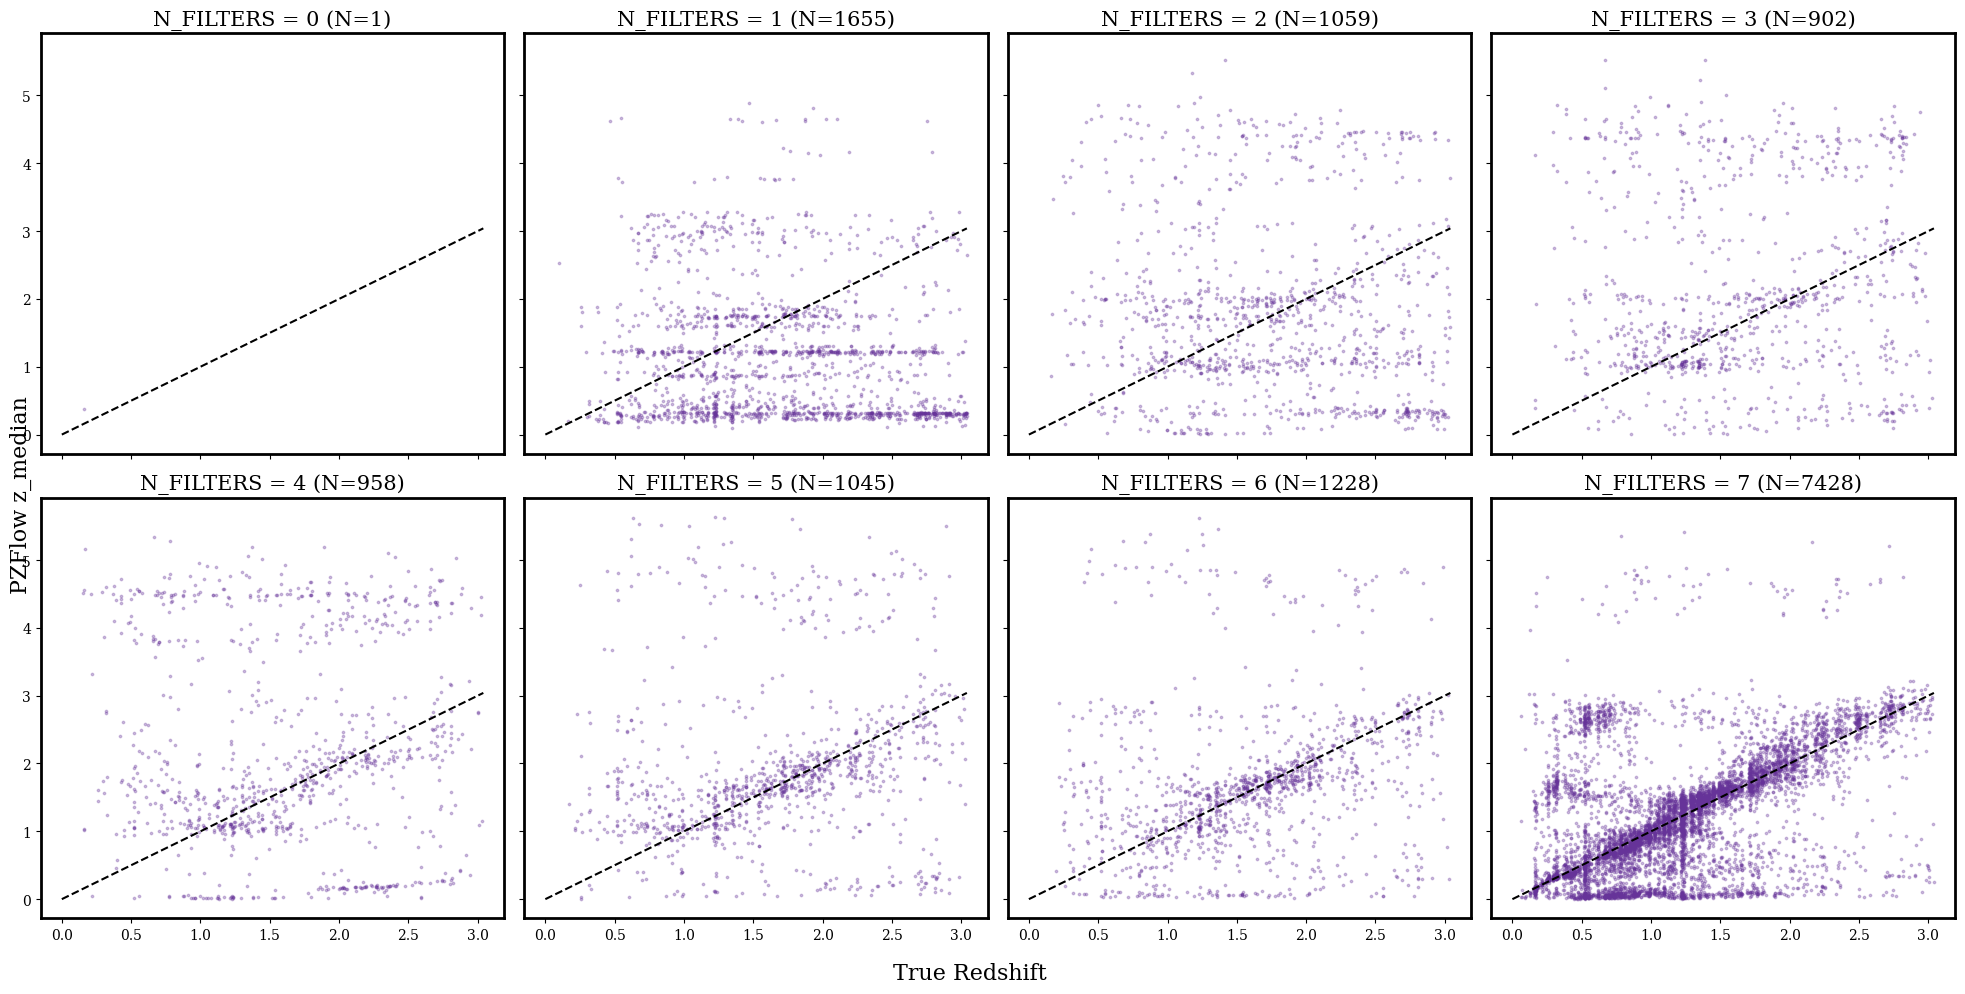

In [53]:
# Galaxy z_median vs. true redshift, split by number of filters detected in
gal = obj_type == 'galaxy'
det_values = np.unique(num_det[gal])

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
axes = axes.flatten()
zmax = np.nanmax(true_z[gal])

for ax, n in zip(axes, det_values):
    sel = gal & (num_det == n)
    ax.scatter(true_z[sel], z_median[sel], s=3, alpha=0.3, color='rebeccapurple')
    ax.plot([0, zmax], [0, zmax], 'k--', lw=1.5)
    ax.set_title(f'N_FILTERS = {n} (N={sel.sum()})', fontsize=15)

# Hide any unused panels
for ax in axes[len(det_values):]:
    ax.axis('off')

fig.supxlabel('True Redshift', fontsize=16)
fig.supylabel('PZFlow z_median', fontsize=16)
plt.tight_layout()
plt.show()

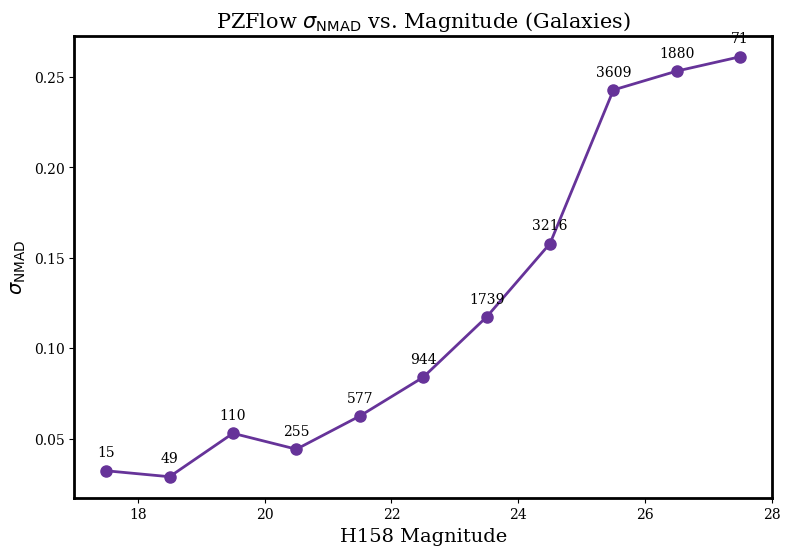

mag [17, 18): N =    15, sigma_NMAD = 0.0322
mag [18, 19): N =    49, sigma_NMAD = 0.0289
mag [19, 20): N =   110, sigma_NMAD = 0.0529
mag [20, 21): N =   255, sigma_NMAD = 0.0441
mag [21, 22): N =   577, sigma_NMAD = 0.0625
mag [22, 23): N =   944, sigma_NMAD = 0.0839
mag [23, 24): N =  1739, sigma_NMAD = 0.1173
mag [24, 25): N =  3216, sigma_NMAD = 0.1579
mag [25, 26): N =  3609, sigma_NMAD = 0.2429
mag [26, 27): N =  1880, sigma_NMAD = 0.2533
mag [27, 28): N =    71, sigma_NMAD = 0.2612


In [61]:
# sigma_NMAD for galaxies as a function of H158 magnitude (1-mag integer bins)
# MAG_H158 == 99 means not detected in that filter, so exclude those
mag_h158 = np.array(main_obj_file['MAG_H158'])
good = (obj_type == 'galaxy') & (mag_h158 < 99) & np.isfinite(z_median) & np.isfinite(true_z)

dz = (z_median[good] - true_z[good]) / (1 + true_z[good])
mags = mag_h158[good]

mag_bins = np.arange(np.floor(mags.min()), np.ceil(mags.max()) + 1)
centers, sig_nmad, counts = [], [], []
for lo in mag_bins[:-1]:
    inbin = (mags >= lo) & (mags < lo + 1)
    if inbin.sum() < 5:  # skip bins too sparse for a meaningful median
        continue
    d = dz[inbin]
    centers.append(lo + 0.5)
    sig_nmad.append(1.4826 * np.median(np.abs(d - np.median(d))))
    counts.append(inbin.sum())

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(centers, sig_nmad, 'o-', color='rebeccapurple', lw=2, markersize=8)
for x, y, n in zip(centers, sig_nmad, counts):
    ax.annotate(f'{n}', (x, y), textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=10)
ax.set_xlabel('H158 Magnitude', fontsize=14)
ax.set_ylabel(r'$\sigma_{\rm NMAD}$', fontsize=14)
ax.set_title(r'PZFlow $\sigma_{\rm NMAD}$ vs. Magnitude (Galaxies)', fontsize=15)
plt.show()

for c, s, n in zip(centers, sig_nmad, counts):
    print(f'mag [{c-0.5:.0f}, {c+0.5:.0f}): N = {n:5d}, sigma_NMAD = {s:.4f}')

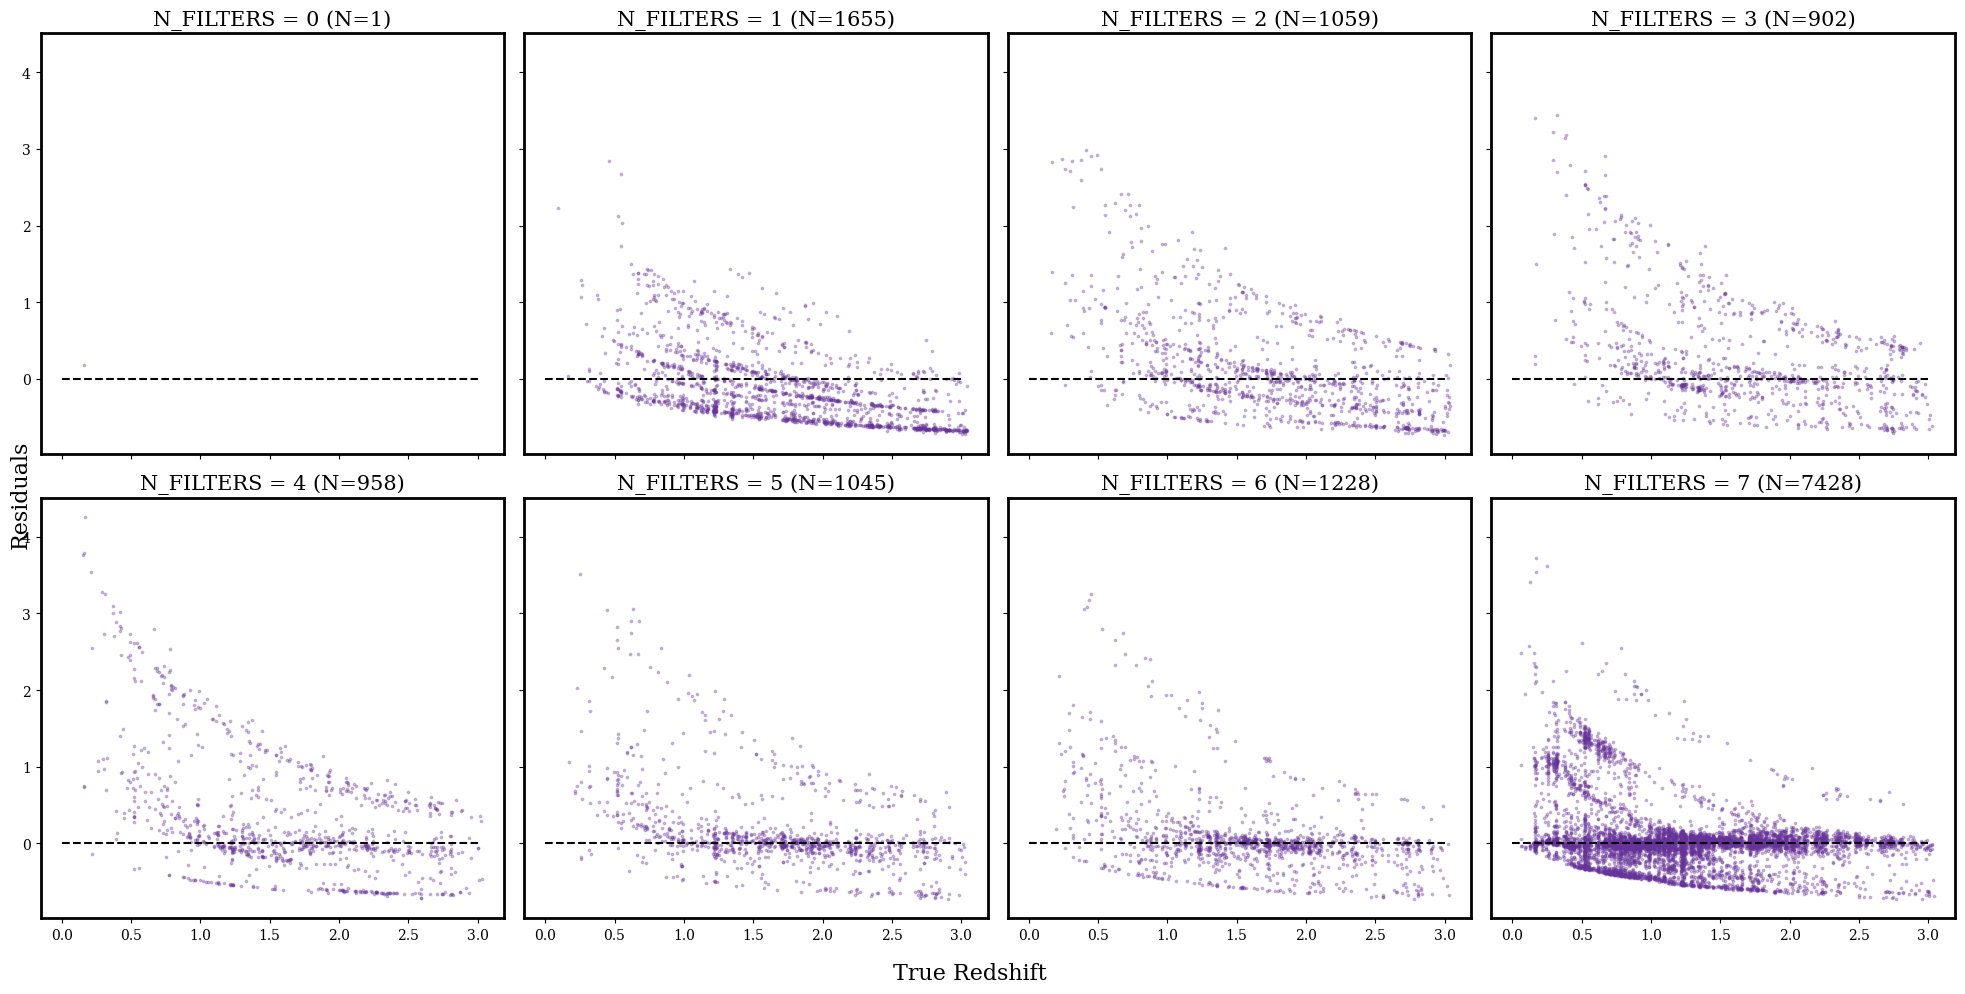

In [60]:
# Galaxy z_median vs. true redshift, split by number of filters detected in
gal = obj_type == 'galaxy'
det_values = np.unique(num_det[gal])

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
axes = axes.flatten()
zmax = np.nanmax(true_z[gal])

for ax, n in zip(axes, det_values):
    sel = gal & (num_det == n)

    residuals_r = (z_median[sel]-true_z[sel])/(1+true_z[sel])
    
    ax.scatter(true_z[sel], residuals_r, s=3, alpha=0.3, color='rebeccapurple')
    ax.plot([0, 3], [0, 0], 'k--', lw=1.5)
    ax.set_title(f'N_FILTERS = {n} (N={sel.sum()})', fontsize=15)

# Hide any unused panels
for ax in axes[len(det_values):]:
    ax.axis('off')

fig.supxlabel('True Redshift', fontsize=16)
fig.supylabel('Residuals', fontsize=16)
plt.tight_layout()
plt.show()

# LePhare

galaxy: 14276 objects, 0 with z_median == NaN
star: 462 objects, 0 with z_median == NaN
transient: 11 objects, 0 with z_median == NaN


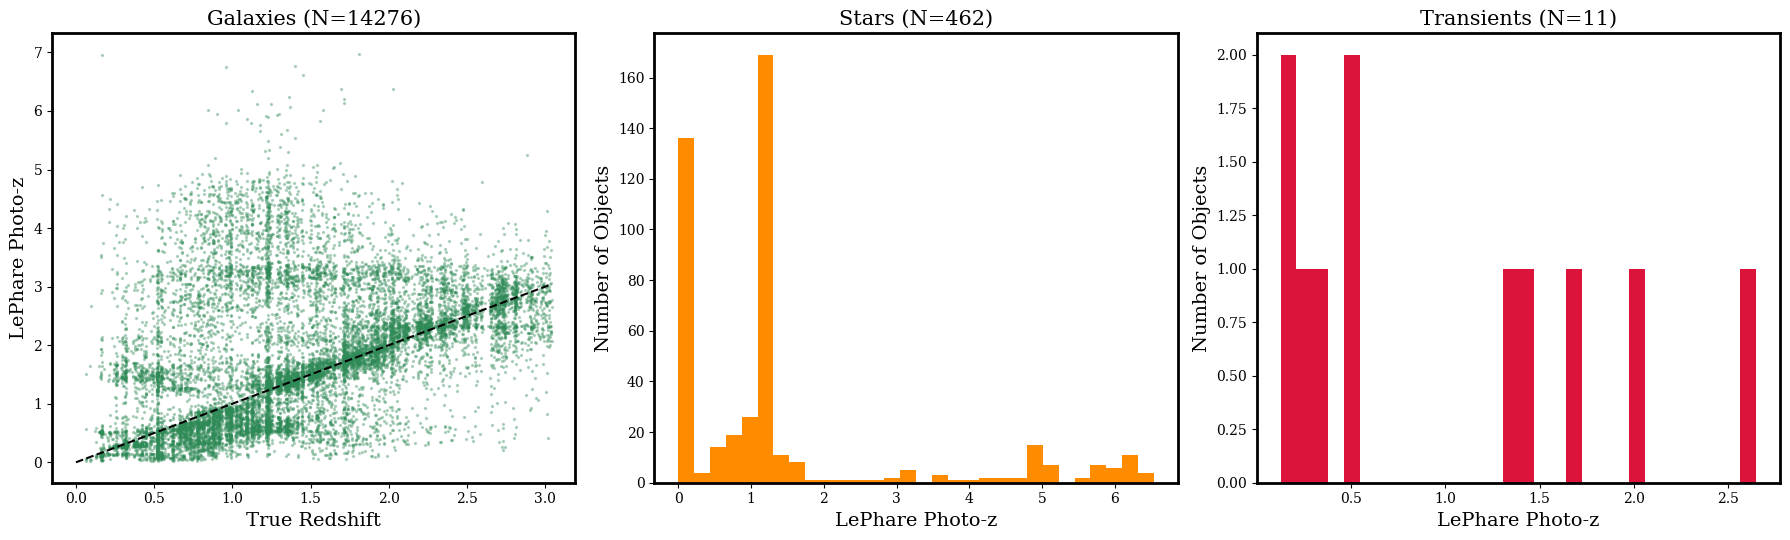

In [62]:
z_median_lp = lephare_res['z_median']

for cat in ['galaxy', 'star', 'transient']:
    sel = obj_type == cat
    print(f'{cat}: {sel.sum()} objects, {np.isnan(z_median_lp[sel]).sum()} with z_median == NaN')

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Galaxies: LePhare z_median vs. true redshift
gal = obj_type == 'galaxy'
axes[0].scatter(true_z[gal], z_median_lp[gal], s=2, alpha=0.3, color='seagreen')
zmax = np.nanmax(true_z[gal])
axes[0].plot([0, zmax], [0, zmax], 'k--', lw=1.5)
axes[0].set_xlabel('True Redshift', fontsize=14)
axes[0].set_ylabel('LePhare Photo-z', fontsize=14)
axes[0].set_title(f'Galaxies (N={gal.sum()})', fontsize=15)

# Stars and transients have no redshift in combined_truth (it comes from the
# galaxy truth file), so show the distribution of their LePhare z_median instead
for ax, cat, color in zip(axes[1:], ['star', 'transient'], ['darkorange', 'crimson']):
    sel = obj_type == cat
    ax.hist(z_median_lp[sel][~np.isnan(z_median_lp[sel])], bins=30, color=color)
    ax.set_xlabel('LePhare Photo-z', fontsize=14)
    ax.set_ylabel('Number of Objects', fontsize=14)
    ax.set_title(f'{cat.capitalize()}s (N={sel.sum()})', fontsize=15)

plt.tight_layout()
plt.show()

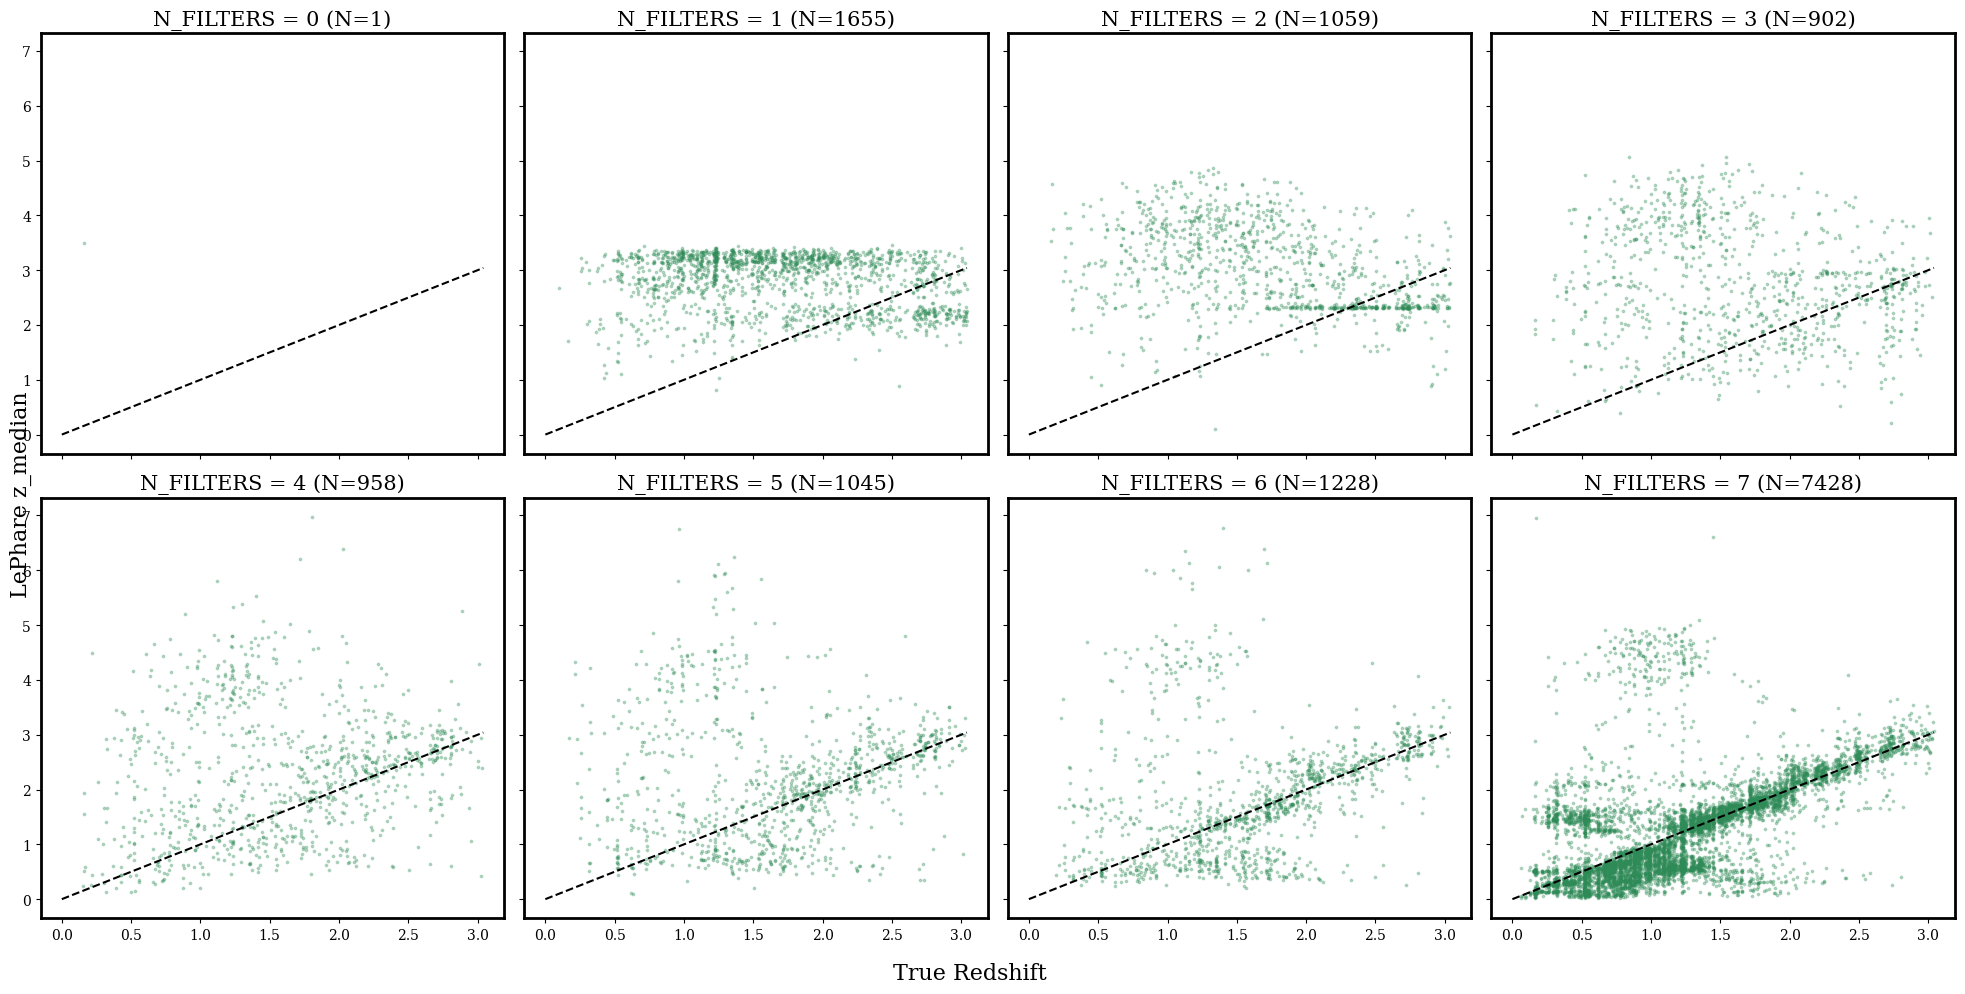

In [63]:
# Galaxy LePhare z_median vs. true redshift, split by number of filters detected in
gal = obj_type == 'galaxy'
det_values = np.unique(num_det[gal])

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
axes = axes.flatten()
zmax = np.nanmax(true_z[gal])

for ax, n in zip(axes, det_values):
    sel = gal & (num_det == n)
    ax.scatter(true_z[sel], z_median_lp[sel], s=3, alpha=0.3, color='seagreen')
    ax.plot([0, zmax], [0, zmax], 'k--', lw=1.5)
    ax.set_title(f'N_FILTERS = {n} (N={sel.sum()})', fontsize=15)

# Hide any unused panels
for ax in axes[len(det_values):]:
    ax.axis('off')

fig.supxlabel('True Redshift', fontsize=16)
fig.supylabel('LePhare Residuals', fontsize=16)
plt.tight_layout()
plt.show()

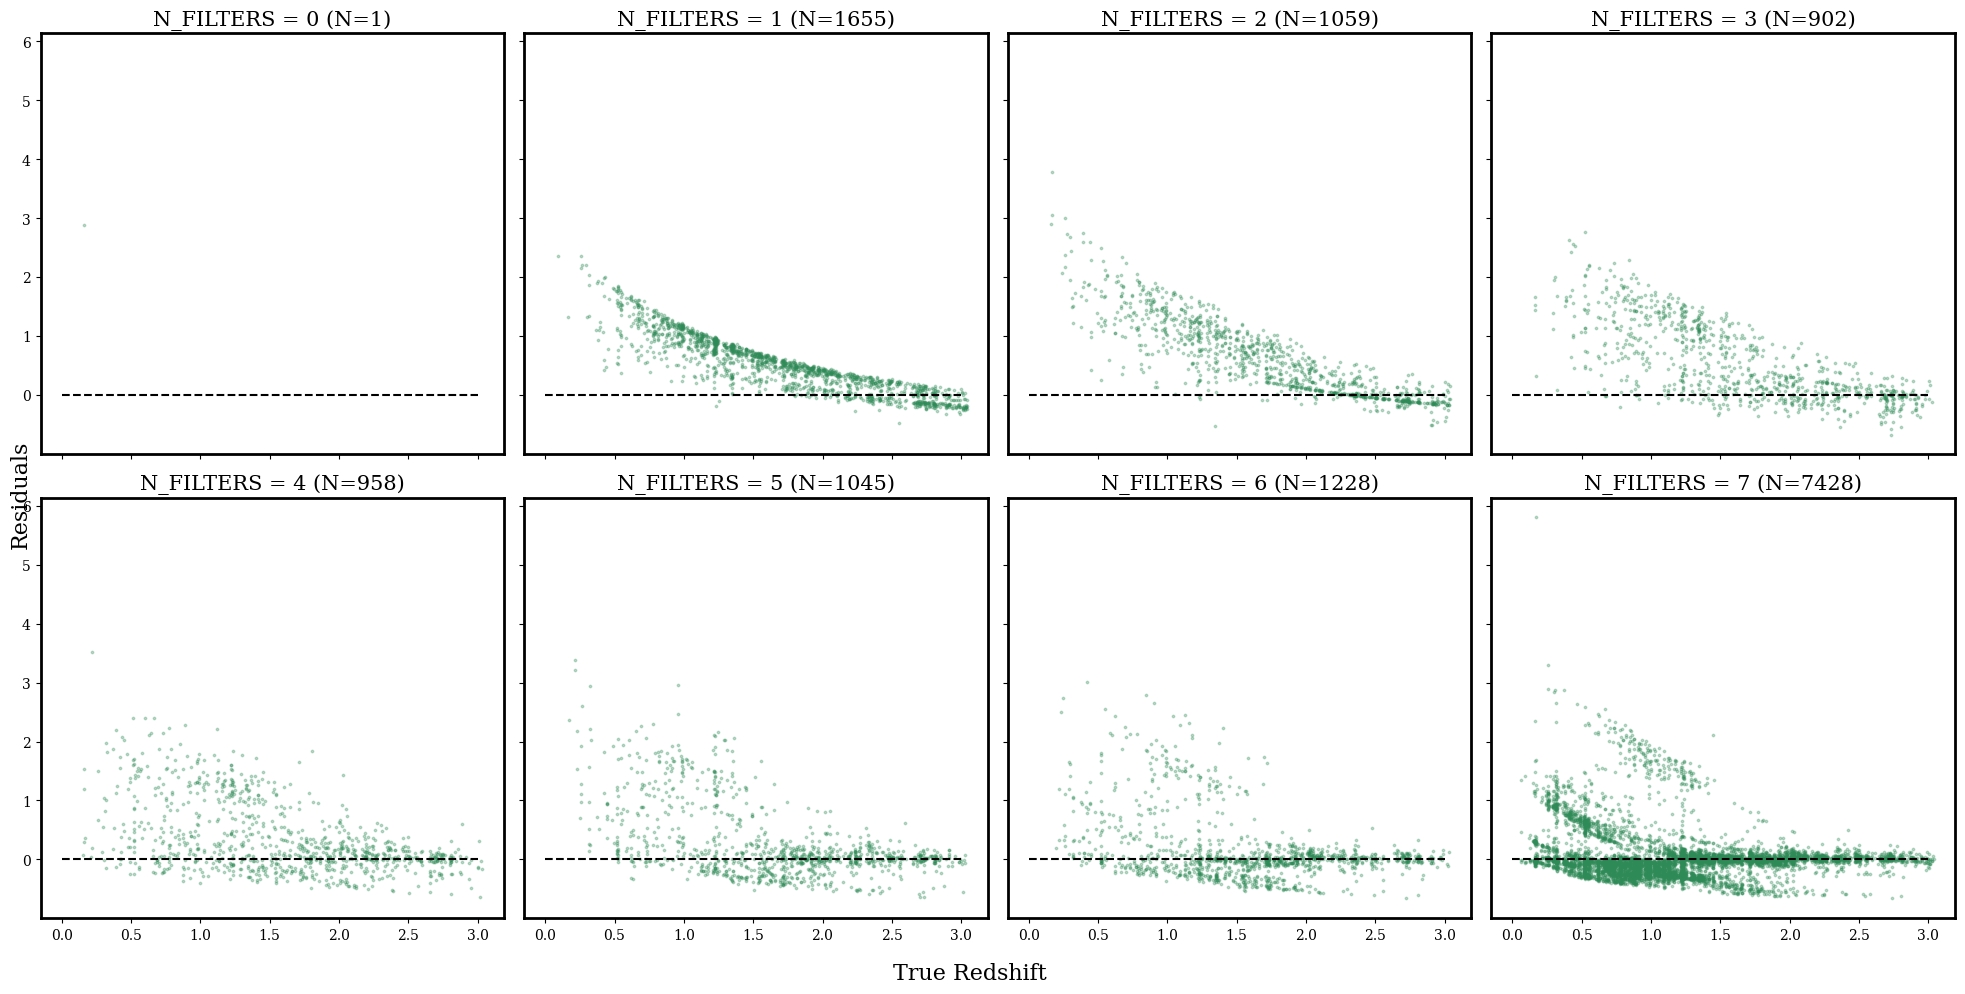

In [64]:
# LePhare residuals vs. true redshift, split by number of filters detected in
gal = obj_type == 'galaxy'
det_values = np.unique(num_det[gal])

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, n in zip(axes, det_values):
    sel = gal & (num_det == n)

    residuals_r = (z_median_lp[sel]-true_z[sel])/(1+true_z[sel])

    ax.scatter(true_z[sel], residuals_r, s=3, alpha=0.3, color='seagreen')
    ax.plot([0, 3], [0, 0], 'k--', lw=1.5)
    ax.set_title(f'N_FILTERS = {n} (N={sel.sum()})', fontsize=15)

# Hide any unused panels
for ax in axes[len(det_values):]:
    ax.axis('off')

fig.supxlabel('True Redshift', fontsize=16)
fig.supylabel('Residuals', fontsize=16)
plt.tight_layout()
plt.show()

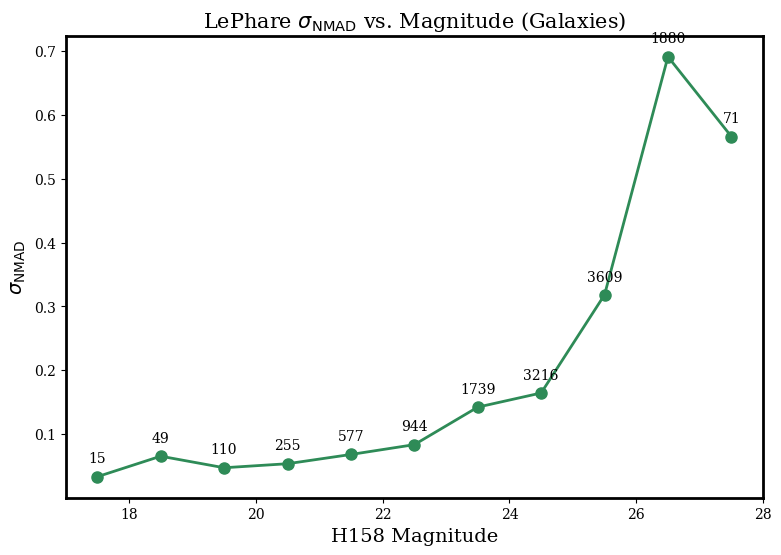

mag [17, 18): N =    15, sigma_NMAD = 0.0334
mag [18, 19): N =    49, sigma_NMAD = 0.0655
mag [19, 20): N =   110, sigma_NMAD = 0.0474
mag [20, 21): N =   255, sigma_NMAD = 0.0537
mag [21, 22): N =   577, sigma_NMAD = 0.0682
mag [22, 23): N =   944, sigma_NMAD = 0.0836
mag [23, 24): N =  1739, sigma_NMAD = 0.1423
mag [24, 25): N =  3216, sigma_NMAD = 0.1645
mag [25, 26): N =  3609, sigma_NMAD = 0.3183
mag [26, 27): N =  1880, sigma_NMAD = 0.6911
mag [27, 28): N =    71, sigma_NMAD = 0.5661


In [65]:
# LePhare sigma_NMAD for galaxies as a function of H158 magnitude (1-mag integer bins)
# MAG_H158 == 99 means not detected in that filter, so exclude those
mag_h158 = np.array(main_obj_file['MAG_H158'])
good = (obj_type == 'galaxy') & (mag_h158 < 99) & np.isfinite(z_median_lp) & np.isfinite(true_z)

dz = (z_median_lp[good] - true_z[good]) / (1 + true_z[good])
mags = mag_h158[good]

mag_bins = np.arange(np.floor(mags.min()), np.ceil(mags.max()) + 1)
centers, sig_nmad, counts = [], [], []
for lo in mag_bins[:-1]:
    inbin = (mags >= lo) & (mags < lo + 1)
    if inbin.sum() < 5:  # skip bins too sparse for a meaningful median
        continue
    d = dz[inbin]
    centers.append(lo + 0.5)
    sig_nmad.append(1.4826 * np.median(np.abs(d - np.median(d))))
    counts.append(inbin.sum())

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(centers, sig_nmad, 'o-', color='seagreen', lw=2, markersize=8)
for x, y, n in zip(centers, sig_nmad, counts):
    ax.annotate(f'{n}', (x, y), textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=10)
ax.set_xlabel('H158 Magnitude', fontsize=14)
ax.set_ylabel(r'$\sigma_{\rm NMAD}$', fontsize=14)
ax.set_title(r'LePhare $\sigma_{\rm NMAD}$ vs. Magnitude (Galaxies)', fontsize=15)
plt.show()

for c, s, n in zip(centers, sig_nmad, counts):
    print(f'mag [{c-0.5:.0f}, {c+0.5:.0f}): N = {n:5d}, sigma_NMAD = {s:.4f}')

# PDF Metrics: PIT KS Test, CDE Loss, and Coverage

In [66]:
# PIT KS and CDE Loss (as in evaluate_photoz.py), computed on matched galaxies only
import qp
import qp.metrics as qpm
from scipy.stats import kstest

gal = obj_type == 'galaxy'

pit_data = {}
print(f"{'Method':<10} {'N':>6} {'PIT KS':>8} {'CDE Loss':>10}")
print('=' * 40)
for name, res in [('PZFlow', pzflow_res), ('LePhare', lephare_res)]:
    z_grid = res['z_grid']
    # Clip any small negative values produced by the estimator
    pdfs = np.clip(res['pdfs'][gal], 0, None)
    zt = true_z[gal]
    # Drop galaxies with NaN/all-zero PDFs or no true redshift
    valid = ~np.isnan(pdfs).any(axis=1) & (pdfs.sum(axis=1) > 0) & np.isfinite(zt)
    pdfs, zt = pdfs[valid], zt[valid]

    ens = qp.Ensemble(qp.interp, data=dict(xvals=z_grid, yvals=pdfs))

    # PIT values + KS statistic on PIT (deviation from uniform)
    pit_vals = qpm.PIT(ens, zt).pit_samps
    ks_stat, ks_p = kstest(pit_vals, 'uniform')
    pit_data[name] = pit_vals

    # CDE loss (lower = better)
    cde_loss = qpm.CDELossMetric(eval_grid=z_grid).evaluate(ens, zt)

    print(f'{name:<10} {valid.sum():>6} {ks_stat:>8.4f} {float(cde_loss):>10.4f}')
print('=' * 40)
print('PIT KS closer to 0 = better (uniform PIT) | CDE Loss lower = better')

Method          N   PIT KS   CDE Loss
PZFlow      14276   0.1416     1.5053
LePhare     14276   0.0466     0.2026
PIT KS closer to 0 = better (uniform PIT) | CDE Loss lower = better


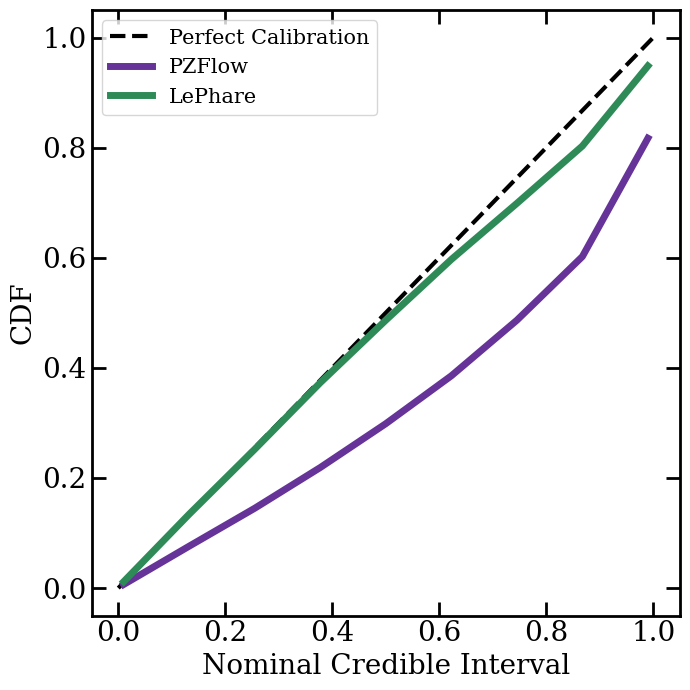

In [67]:
# CDF vs. Nominal Credible Interval (coverage curve, as in Roman Postprocess.ipynb)

def coverage_curve_vectorized(all_chains, true_values, alphas=np.linspace(0.01, 0.99, 9)):
    # Ensure inputs are standard NumPy arrays
    all_chains = np.asarray(all_chains)   # Expected shape: (N, M)
    true_values = np.asarray(true_values) # Expected shape: (N,)

    # Compute all lower and upper quantile probabilities at once
    lowers = (1 - alphas) / 2
    uppers = 1 - lowers
    qs = np.concatenate([lowers, uppers])

    # Compute ALL quantiles for ALL objects simultaneously along axis 1
    quants = np.quantile(all_chains, qs, axis=1)
    n_alphas = len(alphas)
    lo_quants = quants[:n_alphas]
    hi_quants = quants[n_alphas:]

    # Broadcast to check coverage across all alphas at once
    covered = (lo_quants <= true_values[None, :]) & (true_values[None, :] <= hi_quants)
    coverages = np.mean(covered, axis=1)

    return alphas, coverages

def sample_from_pdfs(pdfs, z_grid, n_samples=100, seed=42):
    """
    Draw `n_samples` redshift samples per galaxy from their PDF grids.

    pdfs    : (n_gal, n_z)  — rows are per-galaxy PDFs (need not be normalised)
    z_grid  : (n_z,)        — redshift grid the PDFs are evaluated on
    returns : (n_gal, n_samples)
    """
    rng = np.random.default_rng(seed)

    # Normalise each row to a proper probability mass function
    pmf = pdfs / pdfs.sum(axis=1, keepdims=True)

    # Build CDF per galaxy
    cdf = np.cumsum(pmf, axis=1)

    # Draw uniform random numbers, then invert each galaxy's CDF
    u = rng.uniform(size=(pdfs.shape[0], n_samples))
    samples = np.array([
        np.interp(u[i], cdf[i], z_grid)
        for i in range(pdfs.shape[0])
    ])

    return samples

fig = plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration", lw=3)

for name, res, color in [('PZFlow', pzflow_res, 'rebeccapurple'),
                         ('LePhare', lephare_res, 'seagreen')]:
    pdfs = np.clip(res['pdfs'][gal], 0, None)
    zt = true_z[gal]
    valid = ~np.isnan(pdfs).any(axis=1) & (pdfs.sum(axis=1) > 0) & np.isfinite(zt)

    samples = sample_from_pdfs(pdfs[valid], res['z_grid'], n_samples=1000)
    alphas, cov = coverage_curve_vectorized(samples, zt[valid])
    plt.plot(alphas, cov, label=name, lw=5, color=color)

plt.xlabel("Nominal Credible Interval", fontsize=20)
plt.ylabel("CDF", fontsize=20)
plt.legend(fontsize=15)

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=20, length=10, width=2, direction='in',
                   bottom=True, top=True, left=True, right=True)

plt.tight_layout()
plt.show()